# Exploratory Data Analysis
This notebook analyzes historical sales data to discover trend, weekly, and yearly seasonality patterns.

In [1]:
# Standard library
import sys
import os
sys.path.insert(0, os.path.abspath('..'))

import warnings
warnings.filterwarnings('ignore')

# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

# Statistical decomposition
from statsmodels.tsa.seasonal import seasonal_decompose

# Plot aesthetics
plt.rcParams.update({
    'figure.figsize': (14, 5),
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.family': 'monospace',
    'axes.titlesize': 13,
    'axes.labelsize': 11,
})

print("All imports successful.")

All imports successful.


In [2]:
# Load raw training data
df = pd.read_csv('../data/raw/train.csv', parse_dates=['date'])

# Basic sanity check
print("Shape:", df.shape)
print("\nColumn types:\n", df.dtypes)
print("\nNull values:\n", df.isnull().sum())
print("\nDate range:", df['date'].min(), "→", df['date'].max())
print("\nUnique stores:", df['store'].nunique())
print("\nUnique items:", df['item'].nunique())
print("\nSample rows:")
df.head()

Shape: (913000, 4)

Column types:
 date     datetime64[us]
store             int64
item              int64
sales             int64
dtype: object

Null values:
 date     0
store    0
item     0
sales    0
dtype: int64

Date range: 2013-01-01 00:00:00 → 2017-12-31 00:00:00

Unique stores: 10

Unique items: 50

Sample rows:


,date,store,item,sales
0,2013-01-01,1,1,2
1,2013-01-02,1,1,2
2,2013-01-03,1,1,3
3,2013-01-04,1,1,5
4,2013-01-05,1,1,4


In [3]:
# Aggregate ALL stores and items into one daily series
daily_total = (
    df.groupby('date')['sales']
    .sum()
    .reset_index()
    .set_index('date')
    .sort_index()
)

print("Aggregated daily sales — shape:", daily_total.shape)
daily_total.head()

Aggregated daily sales — shape: (1826, 1)


,sales
date,
2013-01-01,7583
2013-01-02,7827
2013-01-03,8205
2013-01-04,9461
2013-01-05,10585


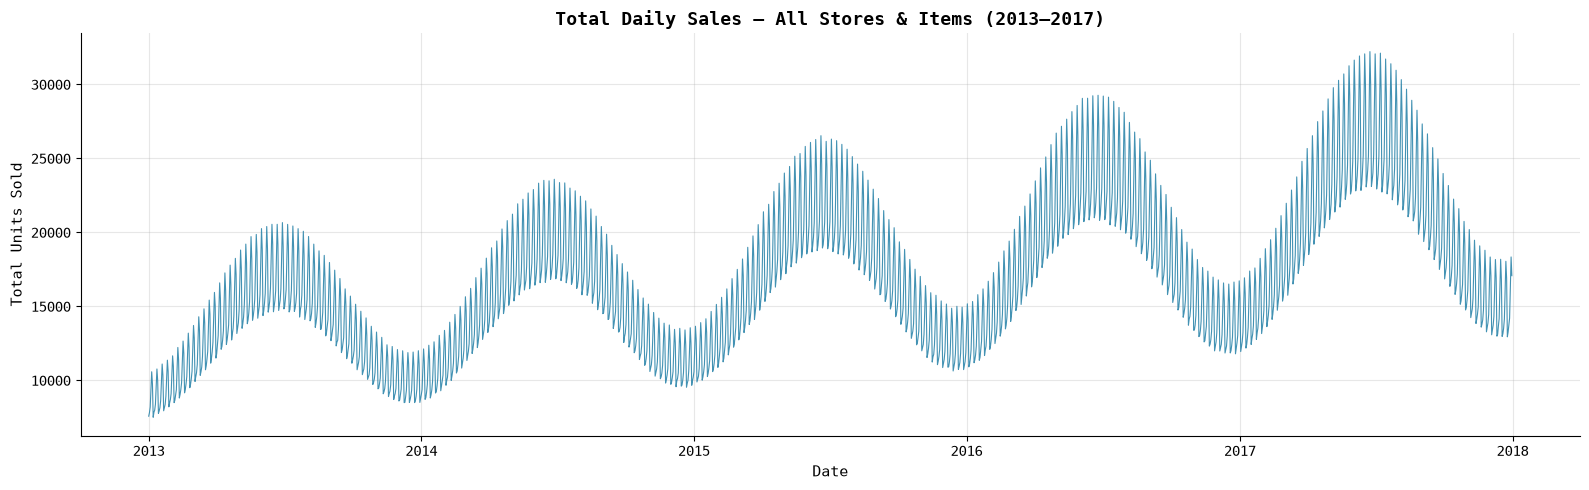

OBSERVATION: Clear upward trend and strong yearly seasonality pattern present.


In [4]:
fig, ax = plt.subplots(figsize=(16, 5))

ax.plot(daily_total.index, daily_total['sales'],
        color='#2E86AB', linewidth=0.8, alpha=0.9)

ax.set_title('Total Daily Sales — All Stores & Items (2013–2017)', fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Total Units Sold')
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.tight_layout()
plt.savefig('../outputs/plots/01_raw_sales_timeseries.png', dpi=150)
plt.show()

print("OBSERVATION: Clear upward trend and strong yearly seasonality pattern present.")

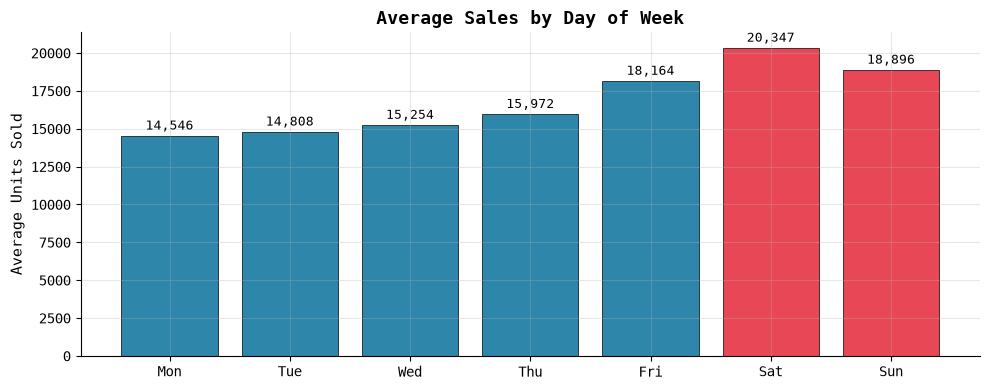

OBSERVATION: Weekend sales are significantly higher than weekday sales.


In [5]:
# Add day of week
daily_total['dayofweek'] = daily_total.index.dayofweek  # 0=Monday, 6=Sunday

fig, ax = plt.subplots(figsize=(10, 4))

day_names = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
avg_by_day = daily_total.groupby('dayofweek')['sales'].mean()

bars = ax.bar(day_names, avg_by_day.values,
              color=['#2E86AB' if i < 5 else '#E84855' for i in range(7)],
              edgecolor='black', linewidth=0.5)

ax.set_title('Average Sales by Day of Week', fontweight='bold')
ax.set_ylabel('Average Units Sold')

# Add value labels on bars
for bar, val in zip(bars, avg_by_day.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
            f'{val:,.0f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('../outputs/plots/02_weekly_pattern.png', dpi=150)
plt.show()

print("OBSERVATION: Weekend sales are significantly higher than weekday sales.")

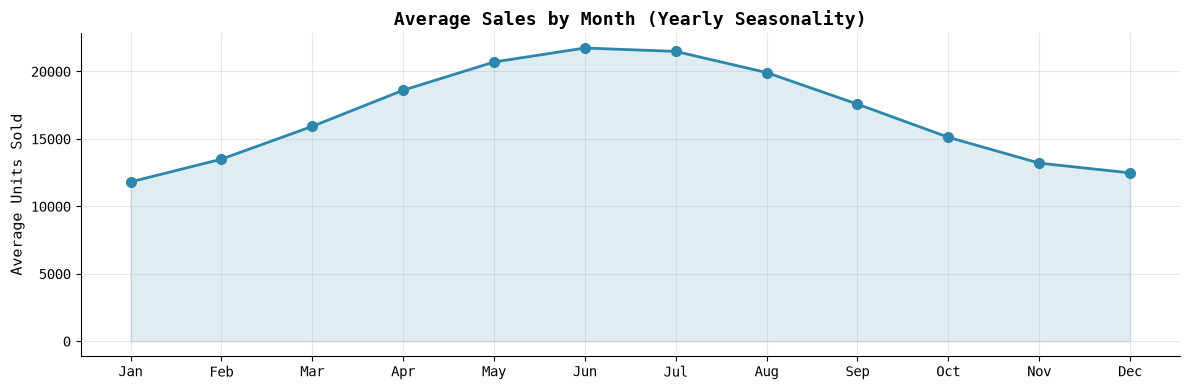

In [6]:
daily_total['month'] = daily_total.index.month

month_names = ['Jan','Feb','Mar','Apr','May','Jun',
               'Jul','Aug','Sep','Oct','Nov','Dec']

avg_by_month = daily_total.groupby('month')['sales'].mean()

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(month_names, avg_by_month.values,
        marker='o', color='#2E86AB', linewidth=2, markersize=7)
ax.fill_between(range(12), avg_by_month.values,
                alpha=0.15, color='#2E86AB')

ax.set_title('Average Sales by Month (Yearly Seasonality)', fontweight='bold')
ax.set_ylabel('Average Units Sold')
ax.set_xticks(range(12))
ax.set_xticklabels(month_names)

plt.tight_layout()
plt.savefig('../outputs/plots/03_monthly_pattern.png', dpi=150)
plt.show()

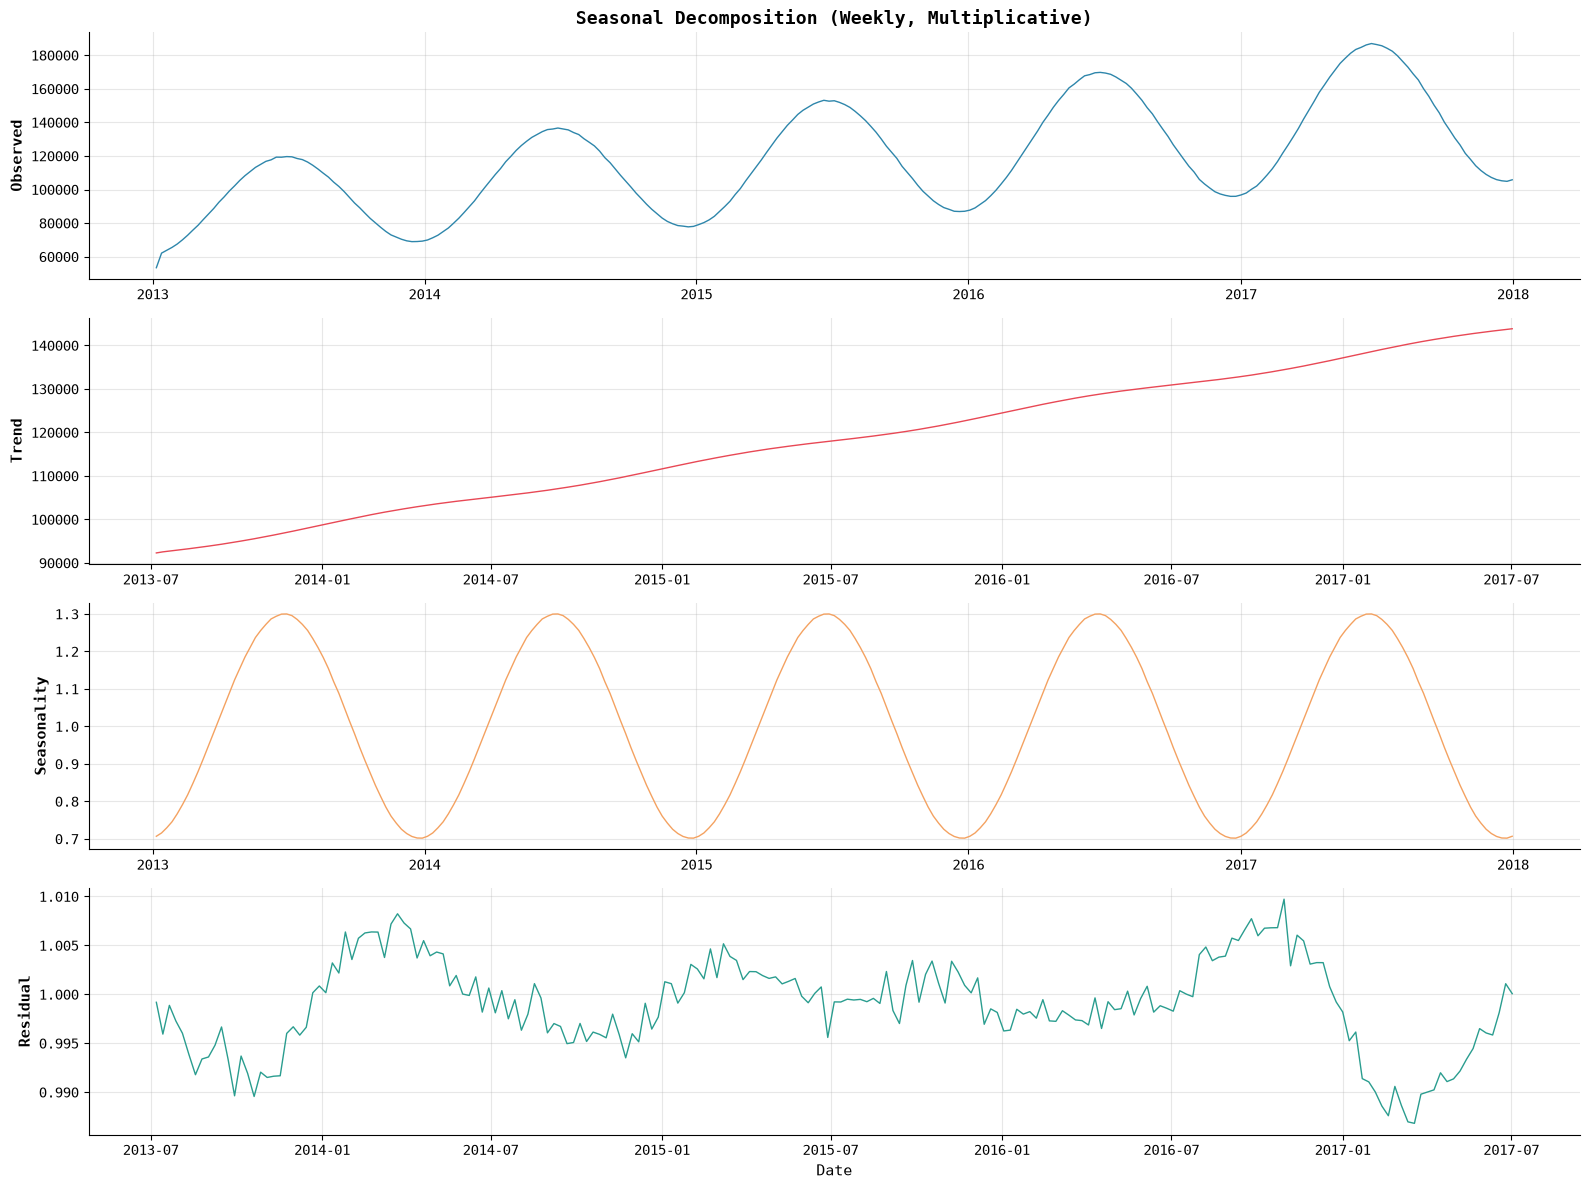

In [7]:
# Decompose into Trend + Seasonality + Residual
# Use weekly resampling to make decomposition cleaner

weekly_total = daily_total['sales'].resample('W').sum()

# Multiplicative decomposition
decomposition = seasonal_decompose(weekly_total, model='multiplicative', period=52)

fig, axes = plt.subplots(4, 1, figsize=(16, 12))

components = {
    'Observed': decomposition.observed,
    'Trend': decomposition.trend,
    'Seasonality': decomposition.seasonal,
    'Residual': decomposition.resid
}

colors = ['#2E86AB', '#E84855', '#F4A261', '#2A9D8F']

for ax, (name, data), color in zip(axes, components.items(), colors):
    ax.plot(data, color=color, linewidth=1)
    ax.set_ylabel(name, fontweight='bold')
    ax.grid(True, alpha=0.3)

axes[0].set_title('Seasonal Decomposition (Weekly, Multiplicative)', fontweight='bold')
axes[-1].set_xlabel('Date')

plt.tight_layout()
plt.savefig('../outputs/plots/04_decomposition.png', dpi=150)
plt.show()

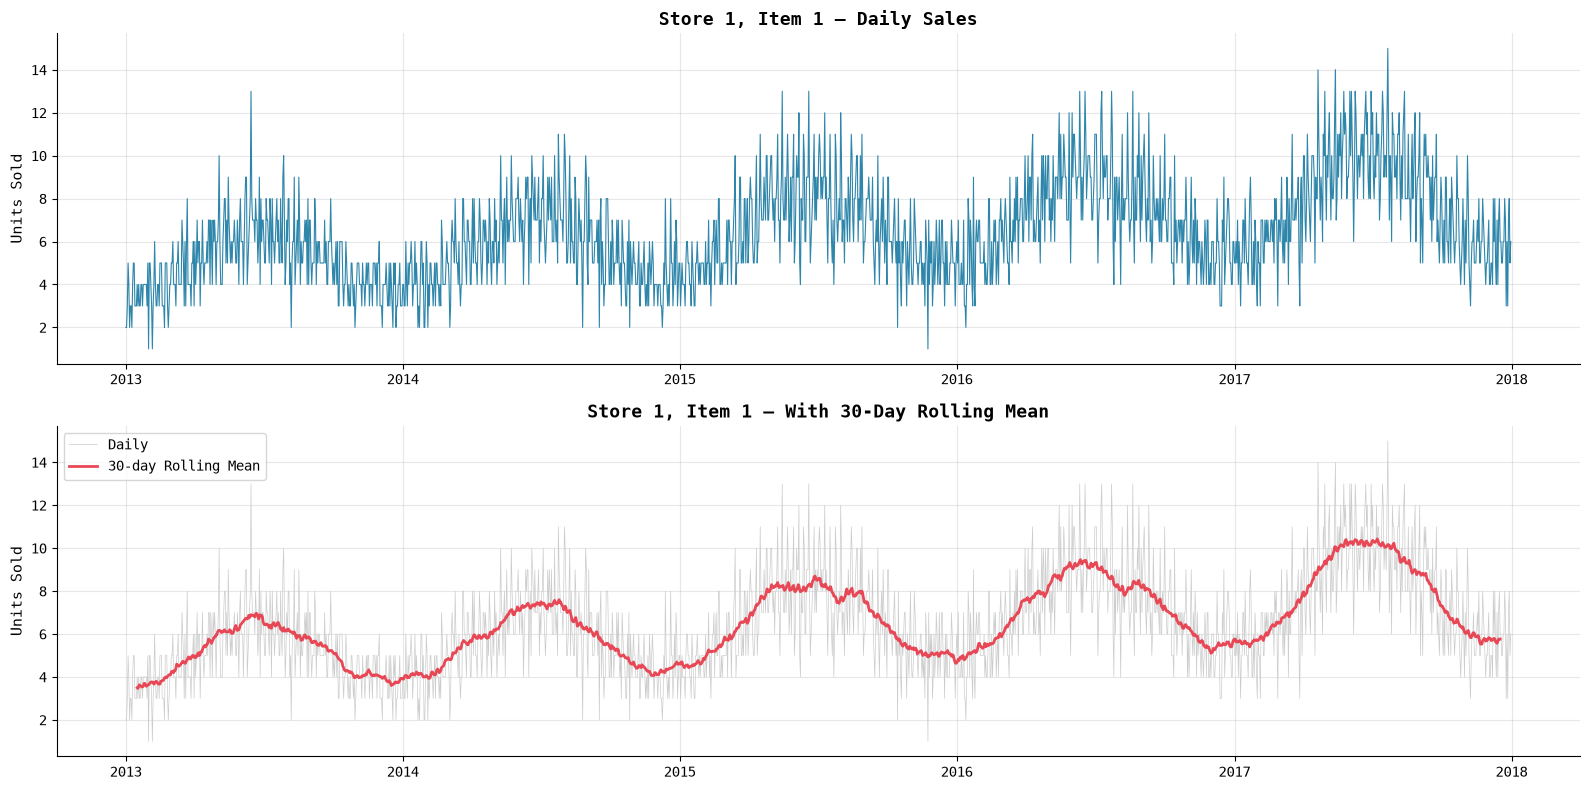

In [8]:
# Pick Store 1, Item 1
s1i1 = df[(df['store'] == 1) & (df['item'] == 1)].set_index('date').sort_index()

fig, axes = plt.subplots(2, 1, figsize=(16, 8))

# Raw series
axes[0].plot(s1i1.index, s1i1['sales'], color='#2E86AB', linewidth=0.8)
axes[0].set_title('Store 1, Item 1 — Daily Sales', fontweight='bold')
axes[0].set_ylabel('Units Sold')

# Rolling 30-day mean overlay
rolling_mean = s1i1['sales'].rolling(30, center=True).mean()
axes[1].plot(s1i1.index, s1i1['sales'], color='#cccccc', linewidth=0.5, label='Daily')
axes[1].plot(s1i1.index, rolling_mean, color='#E84855', linewidth=2, label='30-day Rolling Mean')
axes[1].set_title('Store 1, Item 1 — With 30-Day Rolling Mean', fontweight='bold')
axes[1].set_ylabel('Units Sold')
axes[1].legend()

plt.tight_layout()
plt.savefig('../outputs/plots/05_s1i1_deep_dive.png', dpi=150)
plt.show()

In [9]:
print("""
=== EDA FINDINGS SUMMARY ===

1. Dataset: 913,000 rows | 5 years | 10 stores x 50 items
2. No missing values — clean dataset
3. Clear YEARLY seasonality: sales peak in July and dip in January
4. Clear WEEKLY seasonality: weekends outperform weekdays by ~30%
5. Mild UPWARD TREND across 5 years
6. Decomposition residuals appear mostly random — good sign
7. Individual SKU (Store 1, Item 1) shows consistent patterns

MODELLING IMPLICATIONS:
- Must capture both weekly AND yearly seasonality
- Trend is present — model must handle non-stationarity
- Lag features (yesterday's sales, last week's sales) will be powerful
""")


=== EDA FINDINGS SUMMARY ===

1. Dataset: 913,000 rows | 5 years | 10 stores x 50 items
2. No missing values — clean dataset
3. Clear YEARLY seasonality: sales peak in July and dip in January
4. Clear WEEKLY seasonality: weekends outperform weekdays by ~30%
5. Mild UPWARD TREND across 5 years
6. Decomposition residuals appear mostly random — good sign
7. Individual SKU (Store 1, Item 1) shows consistent patterns

MODELLING IMPLICATIONS:
- Must capture both weekly AND yearly seasonality
- Trend is present — model must handle non-stationarity
- Lag features (yesterday's sales, last week's sales) will be powerful

